In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from data_loader import PairData
from env_v2_07 import PairTradingEnv
from ddqn import DoubleDQN

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class GaussianHybrid(nn.Module):
    """1-D CNN on last 20 z-diffs  +  current z-score  →  (mu, log_var)"""
    def __init__(self, seq_len=20, hidden=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc      = nn.Linear(32 + 1, hidden)
        self.mu_head = nn.Linear(hidden, 1)
        self.lv_head = nn.Linear(hidden, 1)

    def forward(self, x_seq, z_now):
        h = self.conv(x_seq.unsqueeze(1)).squeeze(-1)
        h = torch.cat([h, z_now.unsqueeze(-1)], dim=-1)
        h = F.relu(self.fc(h))
        return self.mu_head(h).squeeze(-1), self.lv_head(h).squeeze(-1)


def gaussian_nll(mu, log_var, y):
    return (log_var + (y - mu) ** 2 / log_var.exp()).mean()


In [2]:
data      = PairData('../../data/real_pair_MCD_YUM.csv')
prices    = data.s
N         = prices.shape[1]
train_end = 3 * N // 4

log_A = np.log(prices[0])
log_B = np.log(prices[1])

# OLS beta on training set
X_ols = np.column_stack([np.ones(train_end), log_B[:train_end]])
coef, _, _, _ = np.linalg.lstsq(X_ols, log_A[:train_end], rcond=None)
intercept_ols, beta_ols = float(coef[0]), float(coef[1])

spread = log_A - beta_ols * log_B - intercept_ols

PAST_WINDOW = 60
LOOKBACK    = 756

print(f'N={N}  train_end={train_end}  test_end={N}')
print(f'OLS beta={beta_ols:.4f}  intercept={intercept_ols:.4f}')


N=5032  train_end=3774  test_end=5032
OLS beta=0.9830  intercept=0.6916


In [3]:
# ── Feature engineering ──────────────────────────────────────────────────
SEQ_LEN = 20

s   = pd.Series(spread)
z_s = pd.Series((spread - spread[:train_end].mean()) / spread[:train_end].std())

ema12     = s.ewm(span=12, adjust=False).mean()
ema26     = s.ewm(span=26, adjust=False).mean()
macd_line = ema12 - ema26
macd_hist = macd_line - macd_line.ewm(span=9, adjust=False).mean()
momentum  = z_s.diff(5)
roll_mean = z_s.rolling(20).mean()
roll_std  = z_s.rolling(20).std()
z_diff    = z_s.diff()

X_ff_raw = np.column_stack([
    z_s.values, momentum.values, macd_line.values,
    macd_hist.values, roll_mean.values, roll_std.values,
])
X_cnn_raw = np.full((N, SEQ_LEN), np.nan)
for t in range(SEQ_LEN - 1, N):
    X_cnn_raw[t] = z_diff.values[t - SEQ_LEN + 1 : t + 1]
y_raw = np.full(N, np.nan)
y_raw[:-1] = z_s.values[1:]

valid_mask = (
    ~np.any(np.isnan(X_ff_raw), axis=1) &
    ~np.any(np.isnan(X_cnn_raw), axis=1) &
    ~np.isnan(y_raw)
)
train_idx = np.where(valid_mask & (np.arange(N) < train_end))[0]
print(f'Hybrid training samples: {len(train_idx)}')

# ── Train ─────────────────────────────────────────────────────────────────
N_HYBRID_EPOCHS = 150
BATCH_SIZE      = 128

hybrid_model = GaussianHybrid(seq_len=SEQ_LEN, hidden=64)
opt = torch.optim.Adam(hybrid_model.parameters(), lr=3e-4)

X_ff_t  = torch.tensor(X_ff_raw[train_idx].astype(np.float32))
X_cnn_t = torch.tensor(X_cnn_raw[train_idx].astype(np.float32))
y_t     = torch.tensor(y_raw[train_idx].astype(np.float32))

ff_mean  = X_ff_t.mean(0, keepdim=True);  ff_std  = X_ff_t.std(0, keepdim=True).clamp(min=1e-8)
cnn_mean = X_cnn_t.mean(0, keepdim=True); cnn_std = X_cnn_t.std(0, keepdim=True).clamp(min=1e-8)

X_ff_n  = (X_ff_t  - ff_mean)  / ff_std
X_cnn_n = (X_cnn_t - cnn_mean) / cnn_std
z_now_t = X_ff_n[:, 0]

loader = DataLoader(TensorDataset(X_cnn_n, z_now_t, y_t), batch_size=BATCH_SIZE, shuffle=True)

hybrid_model.train()
for ep in range(N_HYBRID_EPOCHS):
    ep_loss = 0.0
    for xb_cnn, xb_z, yb in loader:
        opt.zero_grad()
        mu_b, lv_b = hybrid_model(xb_cnn, xb_z)
        loss = gaussian_nll(mu_b, lv_b, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(hybrid_model.parameters(), 1.0)
        opt.step()
        ep_loss += loss.item()
    if (ep + 1) % 50 == 0:
        print(f'  ep {ep+1}/{N_HYBRID_EPOCHS}  loss={ep_loss/len(loader):.4f}')

hybrid_model.eval()
print('Hybrid training done.')

HYBRID_PACK = {
    'model':    hybrid_model,
    'ff_mean':  ff_mean.numpy(),
    'ff_std':   ff_std.numpy(),
    'cnn_mean': cnn_mean.numpy(),
    'cnn_std':  cnn_std.numpy(),
    'seq_len':  SEQ_LEN,
}


Hybrid training samples: 3754
  ep 50/150  loss=-3.2450
  ep 100/150  loss=-3.2701
  ep 150/150  loss=-3.2538
Hybrid training done.


In [4]:
C_EMRT    = 1.0
BETA_GRID = np.arange(0.1, 3.01, 0.01)

def fit_window_emrt(t0, C=C_EMRT):
    A = log_A[t0 - LOOKBACK : t0]
    B = log_B[t0 - LOOKBACK : t0]
    K = len(BETA_GRID)

    Y_mat  = A[np.newaxis, :] - BETA_GRID[:, np.newaxis] * B[np.newaxis, :]
    stds   = Y_mat.std(axis=1, ddof=1)
    mus    = Y_mat.mean(axis=1)
    thresh = C * stds

    lmax = np.maximum.accumulate(Y_mat, axis=1)
    lmin = np.minimum.accumulate(Y_mat, axis=1)
    rmax = np.maximum.accumulate(Y_mat[:, ::-1], axis=1)[:, ::-1]
    rmin = np.minimum.accumulate(Y_mat[:, ::-1], axis=1)[:, ::-1]
    Ym   = Y_mat[:, 1:-1]
    imp  = (
        ((Ym <= Y_mat[:, :-2]) & (Ym <= Y_mat[:, 2:]) &
         (lmax[:, :-2] - Ym >= thresh[:, None]) &
         (rmax[:, 2:]  - Ym >= thresh[:, None])) |
        ((Ym >= Y_mat[:, :-2]) & (Ym >= Y_mat[:, 2:]) &
         (Ym - lmin[:, :-2] >= thresh[:, None]) &
         (Ym - rmin[:, 2:]  >= thresh[:, None]))
    )
    emrts = np.full(K, np.inf)
    for k in range(K):
        if stds[k] < 1e-10: continue
        ext = np.where(imp[k])[0] + 1
        if len(ext) == 0:   continue
        Y_k  = Y_mat[k]; mu_k = mus[k]
        taus = [int(ext[0])]; epos = 1
        while True:
            prev  = taus[-1]
            seg   = Y_k[prev:] - mu_k
            xings = np.where(seg[:-1] * seg[1:] <= 0)[0]
            if xings.size == 0: break
            cross = prev + int(xings[0]) + 1
            taus.append(cross)
            while epos < len(ext) and ext[epos] <= cross:
                epos += 1
            if epos >= len(ext): break
            taus.append(int(ext[epos])); epos += 1
        N_tau = len(taus)
        if N_tau >= 2:
            total    = sum(taus[i] - taus[i-1] for i in range(1, N_tau, 2))
            emrts[k] = (2.0 / N_tau) * total
    best_k = int(np.argmin(emrts))
    beta   = float(BETA_GRID[best_k])
    sp     = A - beta * B
    return beta, float(np.mean(sp))

print('EMRT ready.')


EMRT ready.


In [5]:
def fit_ar1(series):
    y = series[1:]
    X = np.column_stack([np.ones(len(y)), series[:-1]])
    c, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return float(c[0]), float(c[1]), float(np.std(y - X @ c))

def fit_gbm(log_prices):
    r = np.diff(log_prices)
    return float(r.mean()), float(r.std(ddof=1))

EPISODE_LEN = 300
TOTAL_LEN   = PAST_WINDOW + 3 + EPISODE_LEN

print(f'EPISODE_LEN={EPISODE_LEN}  TOTAL_LEN={TOTAL_LEN}')


EPISODE_LEN=300  TOTAL_LEN=363


In [6]:
def gen_episode_emrt(t0):
    beta_ep, icp_ep = fit_window_emrt(t0)
    A_win      = log_A[t0 - LOOKBACK : t0]
    B_win      = log_B[t0 - LOOKBACK : t0]
    spread_win = A_win - beta_ep * B_win - icp_ep

    alpha_ep, phi_ep, sigma_ep = fit_ar1(spread_win)
    stat_mean_ep = alpha_ep / (1.0 - phi_ep)
    mu_B, sigma_B = fit_gbm(B_win)

    eps_s = rng.normal(0,    sigma_ep, TOTAL_LEN)
    eps_B = rng.normal(mu_B, sigma_B,  TOTAL_LEN)

    spread_sim    = np.empty(TOTAL_LEN)
    log_B_sim     = np.empty(TOTAL_LEN)
    spread_sim[0] = stat_mean_ep
    log_B_sim[0]  = B_win[-1]
    for t in range(1, TOTAL_LEN):
        spread_sim[t] = alpha_ep + phi_ep * spread_sim[t-1] + eps_s[t]
        log_B_sim[t]  = log_B_sim[t-1] + eps_B[t]

    log_A_sim = spread_sim + beta_ep * log_B_sim + icp_ep
    return np.exp(np.stack([log_A_sim, log_B_sim])), beta_ep, icp_ep

# sanity check
_p, _b, _ = gen_episode_emrt(LOOKBACK + 100)
print(f'Sanity: prices shape={_p.shape}  beta={_b:.3f}')


Sanity: prices shape=(2, 363)  beta=0.130


In [7]:
# State: [z_score, position, hl_norm, hybrid_mu, hybrid_var]
agent = DoubleDQN(
    state_dim       = 5,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e6),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = 240_000,
    grad_clip       = 1.0,
)
print(f'Agent ready. state_dim=5  eps={agent.epsilon:.3f}')


Agent ready. state_dim=5  eps=1.000


In [8]:
N_EPISODES  = 1800
TRAIN_FREQ  = 4
LOG_EVERY   = 100

T0_MIN = LOOKBACK
T0_MAX = train_end - 1

ep_rewards = []; ep_wealth = []; ep_eps = []; ep_betas = []; losses = []
total_steps = 0

for ep in range(N_EPISODES):
    t0 = int(rng.integers(T0_MIN, T0_MAX + 1))
    prices_syn, beta_ep, icp_ep = gen_episode_emrt(t0)

    env = PairTradingEnv(
        prices_syn, beta=beta_ep, intercept=icp_ep,
        hybrid_pack=HYBRID_PACK,
        past_window=PAST_WINDOW, episode_len=EPISODE_LEN,
    )
    obs, _ = env.reset()
    done = False; ep_r = 0.0

    while not done:
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.replay_buffer.add(obs, action, reward, next_obs, done)
        obs = next_obs; ep_r += reward; total_steps += 1
        if total_steps % TRAIN_FREQ == 0:
            loss = agent.train()
            if loss is not None: losses.append(loss)

    ep_rewards.append(ep_r); ep_wealth.append(env._wealth())
    ep_eps.append(agent.epsilon); ep_betas.append(beta_ep)

    if (ep + 1) % LOG_EVERY == 0:
        print(f'ep {ep+1:5d} | reward {np.mean(ep_rewards[-LOG_EVERY:]):+8.2f} | '
              f'wealth {np.mean(ep_wealth[-LOG_EVERY:]):8.2f} | '
              f'eps {agent.epsilon:.3f} | beta {np.mean(ep_betas[-LOG_EVERY:]):.3f}')


ep   100 | reward  +144.29 | wealth 10144.29 | eps 0.881 | beta 1.332
ep   200 | reward  +414.97 | wealth 10414.97 | eps 0.762 | beta 1.146
ep   300 | reward  +558.63 | wealth 10558.63 | eps 0.644 | beta 1.176
ep   400 | reward  +635.67 | wealth 10635.67 | eps 0.525 | beta 1.172
ep   500 | reward  +726.64 | wealth 10726.64 | eps 0.406 | beta 1.206
ep   600 | reward  +732.48 | wealth 10732.48 | eps 0.287 | beta 1.120
ep   700 | reward  +893.33 | wealth 10893.33 | eps 0.169 | beta 1.246
ep   800 | reward +1234.62 | wealth 11234.62 | eps 0.050 | beta 1.099
ep   900 | reward +1360.63 | wealth 11360.63 | eps 0.050 | beta 1.190
ep  1000 | reward +1429.02 | wealth 11429.02 | eps 0.050 | beta 1.193
ep  1100 | reward +1268.75 | wealth 11268.75 | eps 0.050 | beta 1.111
ep  1200 | reward +1127.49 | wealth 11127.49 | eps 0.050 | beta 1.100
ep  1300 | reward +1450.10 | wealth 11450.10 | eps 0.050 | beta 1.155
ep  1400 | reward +1442.45 | wealth 11442.45 | eps 0.050 | beta 1.306
ep  1500 | reward +1

In [ ]:
# ── Baseline agent: z-score only (no hybrid CNN signal) ───────────────────
# State: [z_score, position, hl_norm]  — same env, first 3 obs only

agent_base = DoubleDQN(
    state_dim       = 3,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e6),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = 240_000,
    grad_clip       = 1.0,
)

base_rewards = []; base_wealth = []; total_steps_b = 0; losses_b = []
rng_b = np.random.default_rng(SEED + 1)   # different seed so episodes differ

for ep in range(N_EPISODES):
    t0 = int(rng_b.integers(T0_MIN, T0_MAX + 1))
    prices_syn, beta_ep, icp_ep = gen_episode_emrt(t0)

    env = PairTradingEnv(
        prices_syn, beta=beta_ep, intercept=icp_ep,
        hybrid_pack=None,          # no hybrid signal
        past_window=PAST_WINDOW, episode_len=EPISODE_LEN,
    )
    obs, _ = env.reset()
    done = False; ep_r = 0.0

    while not done:
        obs3 = obs[:3]             # z, pos, hl_norm
        action = agent_base.select_action(obs3)
        obs, reward, done, _, _ = env.step(action)
        agent_base.replay_buffer.add(obs3, action, reward, obs[:3], done)
        ep_r += reward; total_steps_b += 1
        if total_steps_b % TRAIN_FREQ == 0:
            loss = agent_base.train()
            if loss is not None: losses_b.append(loss)

    base_rewards.append(ep_r); base_wealth.append(env._wealth())

    if (ep + 1) % LOG_EVERY == 0:
        print(f'base ep {ep+1:5d} | reward {np.mean(base_rewards[-LOG_EVERY:]):+8.2f} | '
              f'wealth {np.mean(base_wealth[-LOG_EVERY:]):8.2f} | eps {agent_base.epsilon:.3f}')

print('Baseline training done.')

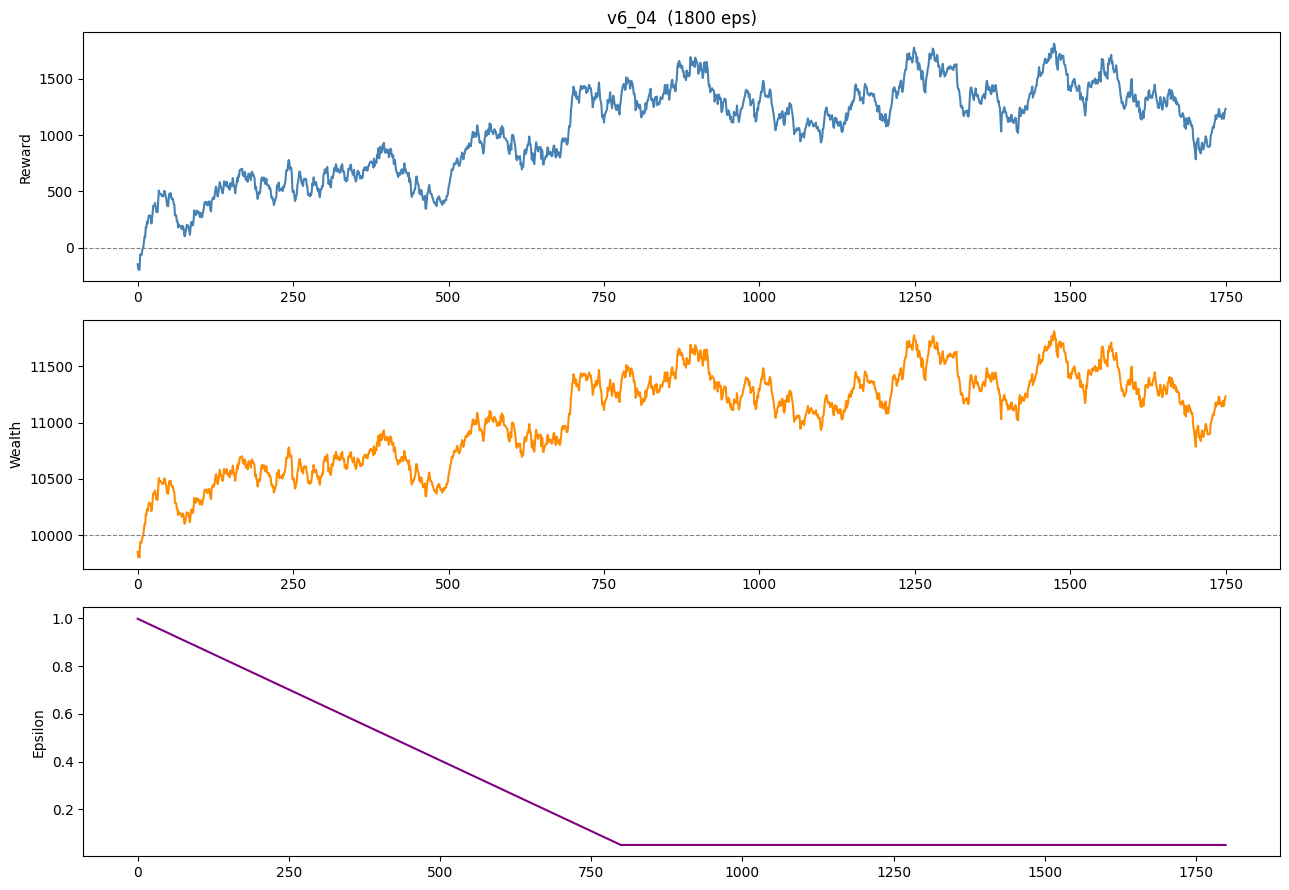

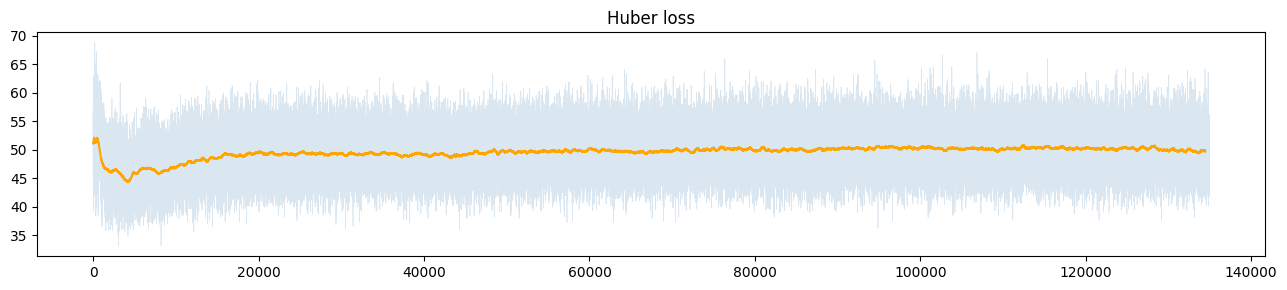

In [9]:
roll = 50; kern = np.ones(roll) / roll

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
axes[0].plot(np.convolve(ep_rewards, kern, mode='valid'), color='steelblue')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_ylabel('Reward'); axes[0].set_title(f'v6_04  ({N_EPISODES} eps)')
axes[1].plot(np.convolve(ep_wealth, kern, mode='valid'), color='darkorange')
axes[1].axhline(10_000, color='gray', lw=0.8, ls='--'); axes[1].set_ylabel('Wealth')
axes[2].plot(ep_eps, color='purple'); axes[2].set_ylabel('Epsilon')
plt.tight_layout(); plt.show()

if losses:
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(losses, alpha=0.2, lw=0.5, color='steelblue')
    ax.plot(np.convolve(losses, np.ones(500)/500, mode='valid'), color='orange', lw=1.5)
    ax.set_title('Huber loss'); plt.tight_layout(); plt.show()


In [10]:
_RF_DAILY = (1.05) ** (1/252) - 1

def make_real_env(t0, initial_wealth=10_000.0):
    beta_ev, icp_ev = fit_window_emrt(t0)
    return PairTradingEnv(
        prices=prices, beta=beta_ev, intercept=icp_ev,
        hybrid_pack=HYBRID_PACK,
        past_window=PAST_WINDOW, initial_wealth=initial_wealth,
    ), beta_ev, icp_ev

def evaluate(env, agent, t_start, t_end):
    env._t = t_start; env._end = t_end
    env._cash = env.initial_wealth; env._shares[:] = 0; env._pos = 0
    obs = env._obs()

    wealth=[env._wealth()]; z_hist=[obs[0]]; pos_hist=[]
    entries_long=[]; entries_short=[]; exits=[]; step=0

    done = False
    while not done:
        prev = env._pos
        action = agent.select_action(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)
        wealth.append(env._wealth()); z_hist.append(float(obs[0])); pos_hist.append(env._pos)
        if env._pos != prev:
            if   env._pos ==  1: entries_long.append(step)
            elif env._pos == -1: entries_short.append(step)
            else:                exits.append(step)
        step += 1

    return dict(wealth=np.array(wealth), z=np.array(z_hist), pos=np.array(pos_hist),
                entries_long=entries_long, entries_short=entries_short, exits=exits,
                t_start=t_start)

def metrics(wealth, label=''):
    W = np.array(wealth); ret = np.diff(W)/W[:-1]; T = len(W)-1
    ann = (W[-1]/W[0])**(252/T)-1
    sr  = ret.mean()/(ret.std()+1e-10)*np.sqrt(252)
    mdd = ((W - np.maximum.accumulate(W))/np.maximum.accumulate(W)).min()*100
    print(f'{label:50s}  ann {ann*100:+.1f}%  Sharpe {sr:.2f}  MDD {mdd:.1f}%  final ${W[-1]:.0f}')
    return ann, sr, mdd


EMRT beta=0.4700  icp=3.0275
v6_04 test [3774-5032]                              ann +7.8%  Sharpe 0.87  MDD -17.6%  final $14521


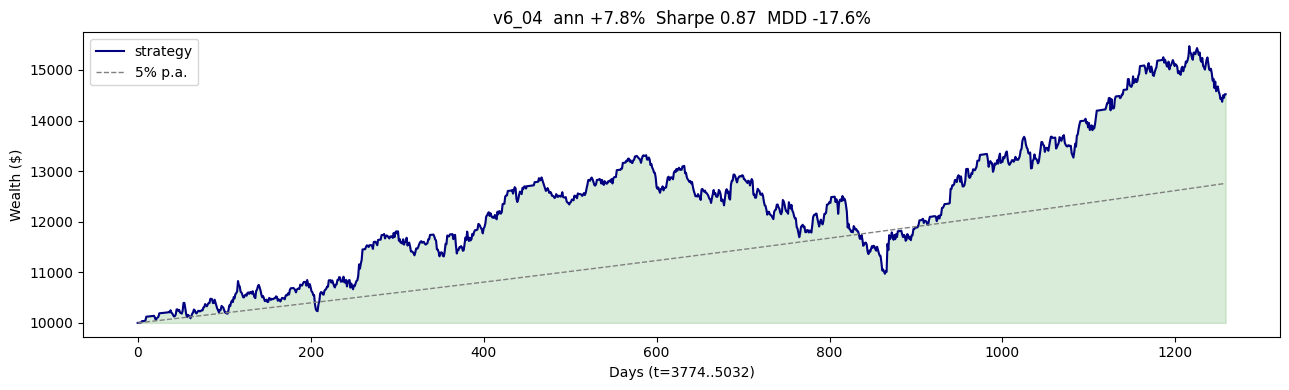

In [11]:
env_test, beta_test, icp_test = make_real_env(train_end)
print(f'EMRT beta={beta_test:.4f}  icp={icp_test:.4f}')

res = evaluate(env_test, agent, t_start=train_end, t_end=N)
ann, sr, mdd = metrics(res['wealth'], f'v6_04 test [{train_end}-{N}]')

# PNL plot
W = res['wealth']; T = len(W)-1
fig, ax = plt.subplots(figsize=(13, 4))
t_ax = np.arange(T+1)
ax.plot(t_ax, W, color='navy', lw=1.5, label='strategy')
ax.plot(t_ax, W[0]*(1+_RF_DAILY)**t_ax, color='gray', lw=1, ls='--', label='5% p.a.')
ax.fill_between(t_ax, W, W[0], where=(W>=W[0]), alpha=0.15, color='green')
ax.fill_between(t_ax, W, W[0], where=(W< W[0]), alpha=0.15, color='red')
ax.set_title(f'v6_04  ann {ann*100:+.1f}%  Sharpe {sr:.2f}  MDD {mdd:.1f}%')
ax.set_ylabel('Wealth ($)'); ax.set_xlabel(f'Days (t={train_end}..{N})'); ax.legend()
plt.tight_layout(); plt.show()


In [14]:
W   = res['wealth']
T   = len(W) - 1
ret = np.diff(W) / W[:-1]

ann_ret = (W[-1] / W[0]) ** (252.0 / T) - 1.0
sharpe  = ret.mean() / (ret.std() + 1e-10) * np.sqrt(252)
peak    = np.maximum.accumulate(W)
mdd     = ((W - peak) / peak).min() * 100

print(f'Test [{train_end} – {N}]  ({T} days)')
print(f'  Annualised return : {ann_ret*100:+.2f}%')
print(f'  Sharpe ratio      : {sharpe:.3f}')
print(f'  Max drawdown      : {mdd:.1f}%')

Test [3774 – 5032]  (1258 days)
  Annualised return : +7.76%
  Sharpe ratio      : 0.870
  Max drawdown      : -17.6%


In [ ]:
# ── Comparison: CNN hybrid agent vs baseline (z-score only) ───────────────

def evaluate_base(env, t_start, t_end):
    """Evaluate baseline agent with obs[:3] only."""
    env._t = t_start; env._end = t_end
    env._cash = env.initial_wealth; env._shares[:] = 0; env._pos = 0
    obs = env._obs()
    wealth = [env._wealth()]; done = False
    while not done:
        action = agent_base.select_action(obs[:3], deterministic=True)
        obs, _, done, _, _ = env.step(action)
        wealth.append(env._wealth())
    return np.array(wealth)

def _report(W, label):
    ret = np.diff(W) / W[:-1]
    ann = (W[-1]/W[0])**(252/len(ret)) - 1
    sr  = ret.mean()/(ret.std()+1e-10)*np.sqrt(252)
    mdd = ((W - np.maximum.accumulate(W))/np.maximum.accumulate(W)).min()*100
    print(f'{label:30s}  {ann*100:>+9.2f}%  {sr:>8.3f}  {mdd:>7.1f}%')
    return ann, sr, mdd

env_cmp_cnn,  _, _ = make_real_env(train_end)
env_cmp_base, _, _ = make_real_env(train_end)

res_cnn  = evaluate(env_cmp_cnn, agent, t_start=train_end, t_end=N)
W_cnn    = res_cnn['wealth']
W_base   = evaluate_base(env_cmp_base, t_start=train_end, t_end=N)
T        = len(W_cnn) - 1

print(f"{'Agent':30s}  {'Ann Ret':>10}  {'Sharpe':>8}  {'MDD':>8}")
print('-' * 62)
ann_c, sr_c, mdd_c = _report(W_cnn,  'CNN hybrid')
ann_b, sr_b, mdd_b = _report(W_base, 'Baseline (z only)')

t_ax = np.arange(T + 1)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(t_ax, W_cnn,  color='steelblue',  lw=1.5,
        label=f'CNN hybrid   ann={ann_c*100:+.1f}%  SR={sr_c:.2f}')
ax.plot(t_ax, W_base, color='darkorange', lw=1.5, ls='--',
        label=f'Baseline z   ann={ann_b*100:+.1f}%  SR={sr_b:.2f}')
ax.plot(t_ax, W_cnn[0]*(1+_RF_DAILY)**t_ax, color='gray', lw=0.8, ls=':', label='5% p.a.')
ax.axhline(W_cnn[0], color='black', lw=0.5, ls='--')
ax.set_ylabel('Wealth ($)'); ax.legend(fontsize=9)
ax.set_title('MCD/YUM — CNN hybrid vs baseline (test set)')

ax = axes[1]
ax.plot(t_ax, W_cnn  - W_cnn[0],  color='steelblue',  lw=1.2, label='CNN hybrid')
ax.plot(t_ax, W_base - W_base[0], color='darkorange', lw=1.2, ls='--', label='Baseline z')
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.set_ylabel('Cumul PnL ($)'); ax.set_xlabel(f'Days (t={train_end}..{N})'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

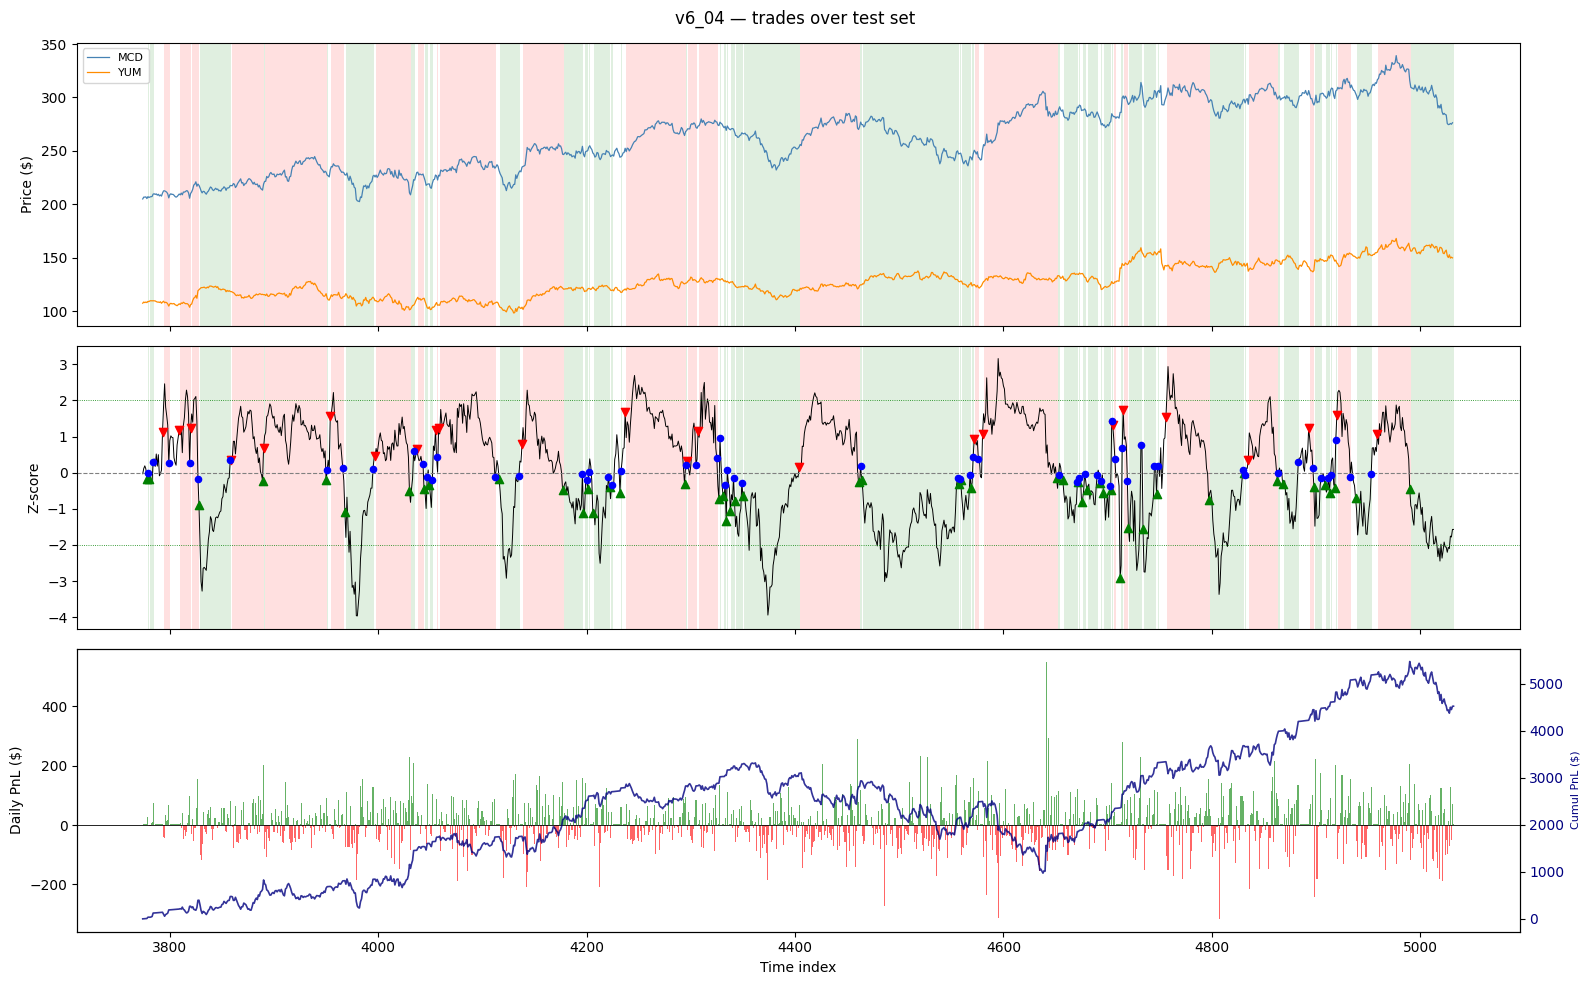

In [12]:
t0    = res['t_start']; T = len(res['z'])-1
t_idx = np.arange(t0, t0+T+1); t_idx_p = t_idx[t_idx < prices.shape[1]]
W = res['wealth']; z = res['z']; pos_ext = np.concatenate([[0], res['pos']])

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('v6_04 — trades over test set', fontsize=12)

ax = axes[0]
ax.plot(t_idx_p, prices[0,t_idx_p], label=data.labels[0], lw=0.9, color='steelblue')
ax.plot(t_idx_p, prices[1,t_idx_p], label=data.labels[1], lw=0.9, color='darkorange')
for i in range(T):
    c = 'green' if pos_ext[i]==1 else ('red' if pos_ext[i]==-1 else None)
    if c: ax.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color=c, lw=0)
ax.set_ylabel('Price ($)'); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(t_idx, z, color='black', lw=0.7)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axhline( 2, color='green', lw=0.6, ls=':'); ax.axhline(-2, color='green', lw=0.6, ls=':')
for i in range(T):
    c = 'green' if pos_ext[i]==1 else ('red' if pos_ext[i]==-1 else None)
    if c: ax.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color=c, lw=0)
for i in res['entries_long']:  ax.scatter(t_idx[i], z[i], color='green', s=35, marker='^', zorder=5)
for i in res['entries_short']: ax.scatter(t_idx[i], z[i], color='red',   s=35, marker='v', zorder=5)
for i in res['exits']:         ax.scatter(t_idx[i], z[i], color='blue',  s=20, marker='o', zorder=5)
ax.set_ylabel('Z-score')

ax = axes[2]
dpnl = np.diff(W)
ax.bar(t_idx[1:], dpnl, color=np.where(dpnl>=0,'green','red'), alpha=0.6, width=1.0)
ax.axhline(0, color='black', lw=0.6)
ax2 = ax.twinx()
ax2.plot(t_idx, W-W[0], color='navy', lw=1.2, alpha=0.8)
ax2.set_ylabel('Cumul PnL ($)', color='navy', fontsize=8)
ax2.tick_params(axis='y', labelcolor='navy')
ax.set_ylabel('Daily PnL ($)'); ax.set_xlabel('Time index')
plt.tight_layout(); plt.show()


In [13]:
import os
os.makedirs('../models', exist_ok=True)
agent.save('../models/mcd_yum_ddqn_v6_04.pt')
print('Saved.')


Saved.
